<table style="width:100%; float:center; background-color:#FFFFFF" align="left">
<tr>
<td style="text-align:left; background-color:#FFFFFF"></td>
<td style="text-align:right; background-color:#FFFFFF"><div>
<image src="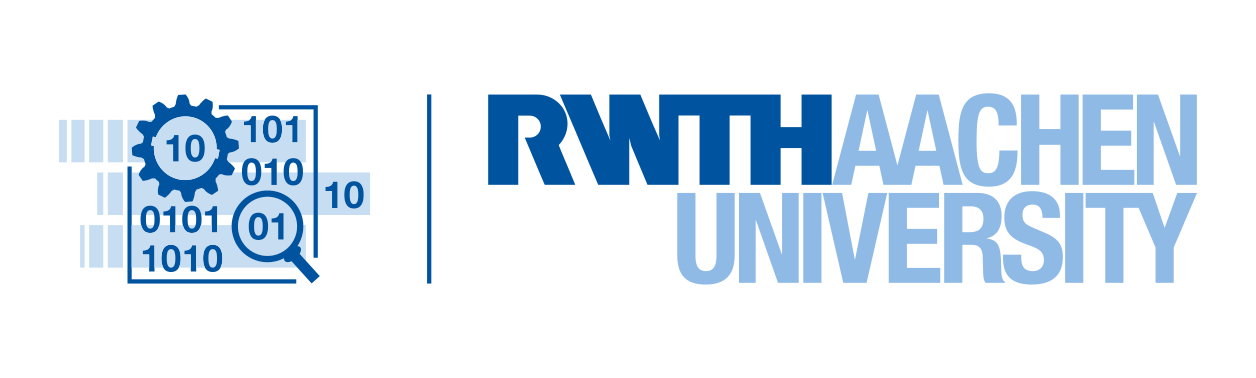" width="500">
    
</div>
</td></tr>
</table>

Prof. Dr. Sandra Geisler <br>
Anastasiia Belova, Soo-Yon Kim

June 30, 2025

<center>

<h1> Data Stream Management and Analysis <br />(Summer Term 2025)</h1>
    
<h1> Exercise 5 - Solution</h1>
    
</center>

---
**Due until Monday, July 14 at 8:00am.  
As solutions, please submit the filled-in Jupyter notebook to moodle.  
Please do _not_ submit handwritten solutions! Your solutions should be submitted in groups of 4 students.**
Solutions to this exercise will be presented on Friday, July 18.

---

### Group members: [Luyang Huang, 466716], [Feiyu Wang, 460101], [Yansong Liu, 453322], [Xingjian Tian, 436949]
#### Insert all group members by double-clicking on this cell.

---

## How to fill in the assignment

For coding tasks, you will find code cells with parts marked with `#YOUR CODE HERE` or  `#IMPLEMENTATION#` or similar.  
Here, insert the required code into that part.

For written tasks, you will find Markdown cells marked with: `Please replace this text with your answer.`  
Here, you can double-click to edit the cell and use [Markdown](https://markdown.de/) to format the answer.  
Mathematical expressions can be created via Latex. For this, enclose the expressions with \$.  

## Task 1 (BIRCH) (4 pts)

As introduced in the lecture, $CF$ is a triple of the form $(N,\vec{LS},SS)$, where  

* $N \in \mathbb{N}$ is  the number of cluster elements

* $\vec{LS} \in \mathbb{R}^d$ is the linear sum vector with $LS_i = \sum_x x_i$

* $SS \in \mathbb{R}$  is the sum of squares with $SS = \sum_{i=1}^d\sum_x x_i^2$

where $\vec{X}$ are d-dimensional items $\vec{X} = (x_1,...,x_d)$ 

Assume that the distance between cluster centroids is measured using the Euclidean distance 

$D = ((\vec{X_1} - \vec{X_2})^2)^{\frac{1}{2}}$

The centroid of a cluster is calculated by

$\vec{X_0} = \frac{\vec{LS}}{N}$

and the radius of a cluster is calculated using

$R = (\frac{\sum_{j=1}^N(\vec{X_j}-\vec{X_0})^2}{N})^\frac{1}{2} = (\frac{SS}{N}-(\frac{\vec{LS}}{N})^2)^\frac{1}{2}$

Consider the following data points from a stream with two-dimensional real-valued data coming in one by one:

(2,3) (4,5) (3,8) (5,7)

Apply the first phase of the BIRCH algorithm, parameterized with branching factor B=2 (non-leafs) and radius R=2, on each incoming data item. 

Draw the CF tree after each change in the tree and indicate the values for CF for each node and leaf. 

Note: when rounding is necessary, round to the first digit after the decimal point only.

(2,3) arrives</br>
Leaf $C_1$ has entry $L_1$ with $CF_1$ = (1, (2,3), 13</br>

(4,5) arrvies directly at $C_1$ -> update $CF_1$ = (2,(6,8),54)</br>
calculate new centriod $\vec{X_1}$ = (3,4)</br>
calculate radius $R_1 = \sqrt{27 - (9+16)} = 1.4 < R$</br>
absorb (4,5) in $L_1$ = $CF_1$ = (2,(6,8),54)</br>

(3,8) arrives directly at $C_1$ -> update $CF_1$ = (3,(9,16),127)</br>
calculate new centriod $\vec{X_1}$ = (3,16/3)</br>
calculate radius $R_1 = sqrt{127/3 - (9+256/9)} = 2.2 > R$</br>
create new entry $L_2$ with $CF_2$ = (1,(3,8),73)</br>

(5,7) arrives $D_{CF_1}=\sqrt{13} < D_{CF_2}=\sqrt{5} \to$ update $CF_2$ = (2,(8,15),147)</br>
calculate new centriod $\vec{X_2}$ = (4,7.5)</br>
calculate radius $R_2 = \sqrt{147/2 - (16+225/4)} = 1.1 > R$</br>
absorb (5,7) in $L_2$ with $CF_2$ = (1,(3,8),73)

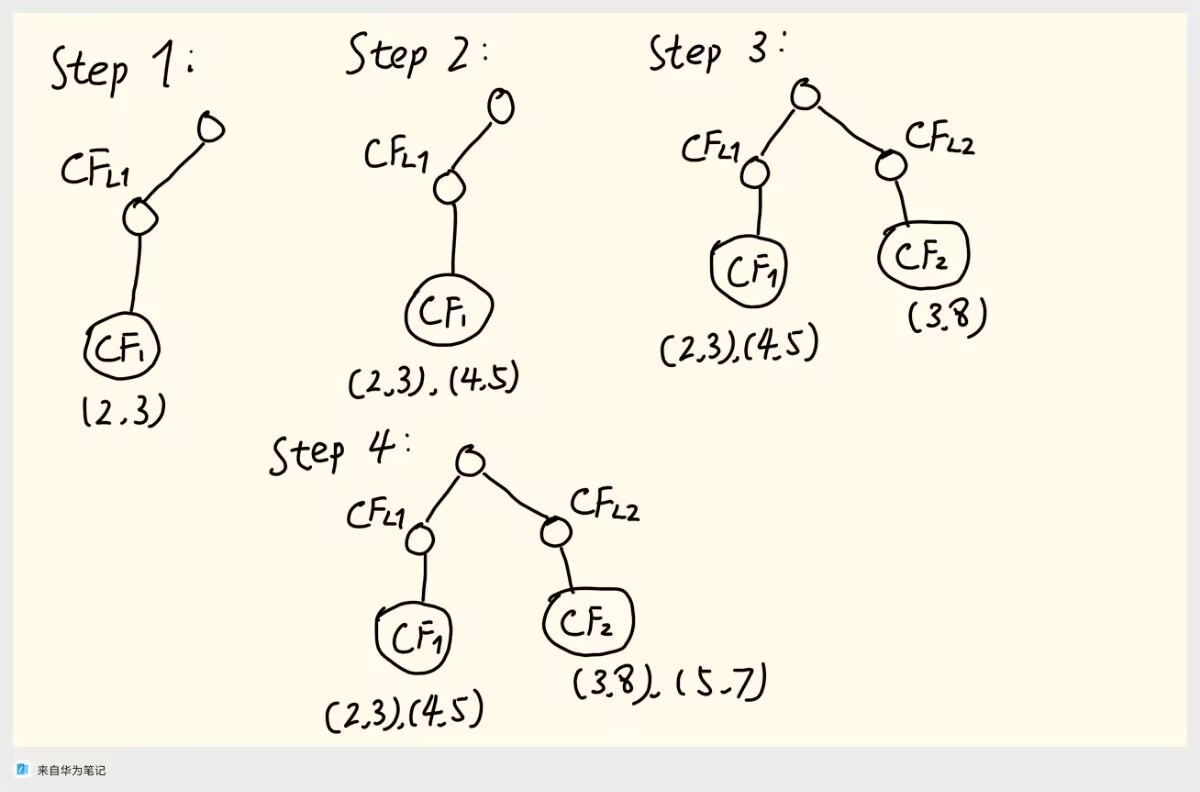

## Task 2 (Learning under Change) (8 pts)

**Some important points to note for this task:**
* This task uses the scikit-multiflow library.
* If scikit-multiflow does not work, the river library is a valid alternative.
* You can use the same environment as was provided in Exercise 4.
* Agarwal generator is used to create the data stream for the task. It has 6 numeric and 3 categorical features - https://scikit-multiflow.readthedocs.io/en/stable/api/generated/skmultiflow.data.AGRAWALGenerator.html#skmultiflow.data.AGRAWALGenerator . First we use a normal data stream and introduce a stream with concept drift stream later.
* Remember to reset the classifier variables between parts, if being reused, so that non of the classifiers are pretrained.
* Some development environments like Visual Studio Code might not render the dynamic graphs properly. Using the normal Jupyter Notebook app is recommended.

In [1]:
%matplotlib notebook

# Imports
from skmultiflow.drift_detection.adwin import ADWIN
from skmultiflow.trees import HoeffdingTreeClassifier,HoeffdingAdaptiveTreeClassifier
from skmultiflow.data import RandomRBFGeneratorDrift,ConceptDriftStream,AGRAWALGenerator
from skmultiflow.evaluation import EvaluatePrequential,EvaluateHoldout
from skmultiflow.neural_networks import PerceptronMask
from skmultiflow.meta import OzaBaggingADWINClassifier,AdaptiveRandomForestClassifier,AccuracyWeightedEnsembleClassifier,LearnPPNSEClassifier

In [2]:
# Don't modify

nom_attr = ["elevel","car","zipcode"]
stream = AGRAWALGenerator(random_state=112)

# stream.next_sample(5) prints the first 5 samples of the stream.

evaluator = EvaluatePrequential(max_samples=50000,
                                batch_size=100,
                                show_plot=True,
                                metrics=['accuracy', 'kappa'])

ht_nb_classifier = HoeffdingTreeClassifier(leaf_prediction='nb',nominal_attributes=nom_attr)
ht_mc_classifier = HoeffdingTreeClassifier(leaf_prediction='mc',nominal_attributes=nom_attr)
ht_nba_classifier = HoeffdingTreeClassifier(leaf_prediction='nba',nominal_attributes=nom_attr)
aht_classifier = HoeffdingAdaptiveTreeClassifier(nominal_attributes=nom_attr)

1\. Train two Hoeffding Tree classifiers on the given stream, each with a different prediction mechanism at their leafs, namely `Naive Bayes` and `Majority Class`. 
To that end perform a prequential evaluation of the classifiers using the metrics `accuracy` and `kappa`. Which classifier performs better here? 

In [3]:
# Your Code
# Evaluate both classifiers
evaluator.evaluate(stream=stream, 
                  model=[ht_nb_classifier, ht_mc_classifier],
                  model_names=['HT-NB', 'HT-MC'])

<IPython.core.display.Javascript object>

D:\anaconda3\envs\dsma-ex\lib\site-packages\skmultiflow\visualization\evaluation_visualizer.py:185: MatplotlibDeprecationWarning: 
The set_window_title function was deprecated in Matplotlib 3.4 and will be removed two minor releases later. Use manager.set_window_title or GUI-specific methods instead.
  self.fig.canvas.set_window_title('scikit-multiflow')


Prequential Evaluation
Evaluating 1 target(s).
Pre-training on 200 sample(s).
Evaluating...
 #################### [100%] [52.79s]
Processed samples: 50000
Mean performance:
HT-NB - Accuracy     : 0.9950
HT-NB - Kappa        : 0.9887
HT-MC - Accuracy     : 0.9898
HT-MC - Kappa        : 0.9769


[HoeffdingTreeClassifier(binary_split=False, grace_period=200,
                         leaf_prediction='nb', max_byte_size=33554432,
                         memory_estimate_period=1000000, nb_threshold=0,
                         no_preprune=False,
                         nominal_attributes=['elevel', 'car', 'zipcode'],
                         remove_poor_atts=False, split_confidence=1e-07,
                         split_criterion='info_gain', stop_mem_management=False,
                         tie_threshold=0.05),
 HoeffdingTreeClassifier(binary_split=False, grace_period=200,
                         leaf_prediction='mc', max_byte_size=33554432,
                         memory_estimate_period=1000000, nb_threshold=0,
                         no_preprune=False,
                         nominal_attributes=['elevel', 'car', 'zipcode'],
                         remove_poor_atts=False, split_confidence=1e-07,
                         split_criterion='info_gain', stop_mem_management=Fal

Naivew Bayes classifier performs better here.

2\. You are given the following `ConceptDriftStream` for the following tasks.

In [4]:
# Don't modify
drift_stream = ConceptDriftStream(random_state=112)

A. Using `ADWIN` drift detection method, print out the indexes at which the concept drift occurs in the stream for the first 20,000 samples. Also print the new window size when drift is detected.


In [5]:
# Your Code
# Initialize ADWIN detector
adwin = ADWIN()

# Process stream and detect drifts
drift_points = []
window_sizes = []
sample_count = 0

while sample_count < 20000:
    X, y = drift_stream.next_sample()
    adwin.add_element(y[0])  # Monitor the target variable
    
    if adwin.detected_change():
        drift_points.append(sample_count)
        window_sizes.append(adwin.width)
    
    sample_count += 1

print("Drift detected at samples:", drift_points)
print("ADWIN window sizes at detection:", window_sizes)

Drift detected at samples: [6943, 7167, 7871]
ADWIN window sizes at detection: [5920, 3072, 3264]


B. Use a `Hoeffding Tree` and a `Hoeffding Adaptive Tree` classifier with leaf_prediction as `Naive Bayes Adaptive` and the previously used naive bayes Hoeffding Tree classifier. Compare them using prequential evaluation. Compare and pick a `batch_size` between 100 and 500 that differentiates the classifiers reasonably well.

In [11]:
# Your Code
# Define batch sizes to test
batch_sizes = [100, 200, 300, 400, 500]
# Initialize 
aht_nba_classifier = HoeffdingAdaptiveTreeClassifier(leaf_prediction='nba', nominal_attributes=nom_attr)

for batch_size in batch_sizes:
    print(f"\nEvaluating with batch_size = {batch_size}")
    
    # Prequential Evaluator
    evaluator = EvaluatePrequential(
        max_samples=50000,
        batch_size=batch_size,
        show_plot=True,
        metrics=['accuracy', 'kappa'],
        n_wait=100
    )
    
    # Evaluate all 4 models
    evaluator.evaluate(
        stream=drift_stream,
        model=[ht_nb_classifier, ht_nba_classifier, aht_nba_classifier],
        model_names=['HT-NB', 'HT-NBA', 'AHT-NBA']
    )


Evaluating with batch_size = 100


<IPython.core.display.Javascript object>

D:\anaconda3\envs\dsma-ex\lib\site-packages\skmultiflow\visualization\evaluation_visualizer.py:185: MatplotlibDeprecationWarning: 
The set_window_title function was deprecated in Matplotlib 3.4 and will be removed two minor releases later. Use manager.set_window_title or GUI-specific methods instead.
  self.fig.canvas.set_window_title('scikit-multiflow')


Prequential Evaluation
Evaluating 1 target(s).
Pre-training on 200 sample(s).
Evaluating...
 #################### [100%] [210.21s]
Processed samples: 50000
Mean performance:
HT-NB - Accuracy     : 0.9470
HT-NB - Kappa        : 0.8934
HT-NBA - Accuracy     : 0.9474
HT-NBA - Kappa        : 0.8941
AHT-NBA - Accuracy     : 0.9778
AHT-NBA - Kappa        : 0.9551

Evaluating with batch_size = 200


<IPython.core.display.Javascript object>

...

D:\anaconda3\envs\dsma-ex\lib\site-packages\skmultiflow\visualization\evaluation_visualizer.py:185: MatplotlibDeprecationWarning: 
The set_window_title function was deprecated in Matplotlib 3.4 and will be removed two minor releases later. Use manager.set_window_title or GUI-specific methods instead.
  self.fig.canvas.set_window_title('scikit-multiflow')


Prequential Evaluation
Evaluating 1 target(s).
Pre-training on 200 sample(s).
Evaluating...
 #################### [100%] [186.55s]
Processed samples: 50200
Mean performance:
HT-NB - Accuracy     : 0.9499
HT-NB - Kappa        : 0.8991
HT-NBA - Accuracy     : 0.9502
HT-NBA - Kappa        : 0.8997
AHT-NBA - Accuracy     : 0.9548
AHT-NBA - Kappa        : 0.9086

Evaluating with batch_size = 500


<IPython.core.display.Javascript object>

D:\anaconda3\envs\dsma-ex\lib\site-packages\skmultiflow\visualization\evaluation_visualizer.py:185: MatplotlibDeprecationWarning: 
The set_window_title function was deprecated in Matplotlib 3.4 and will be removed two minor releases later. Use manager.set_window_title or GUI-specific methods instead.
  self.fig.canvas.set_window_title('scikit-multiflow')


Prequential Evaluation
Evaluating 1 target(s).
Pre-training on 200 sample(s).
Evaluating...
 #################### [99%] [176.63s]
Processed samples: 50200
Mean performance:
HT-NB - Accuracy     : 0.9491
HT-NB - Kappa        : 0.8976
HT-NBA - Accuracy     : 0.9490
HT-NBA - Kappa        : 0.8974
AHT-NBA - Accuracy     : 0.9580
AHT-NBA - Kappa        : 0.9150


C. What change do you see in the performance of the classifier chosen from part 1, when evaluated on the concept drift stream (compared to the normal stream in part 1). Discuss the reason for the change.

Classifier chosen from part 1 performs worse in drift stream. Naive Bayes assumes stable data distribution and does not adopt any method to forget old data that occurs before concept drift.

D. Which is the best and the worst performing classifier in (B) ?

Best performing classifier is Hoeffding Adaptive Tree classifier with leaf_prediction as Naive Bayes Adaptive.
Worst performing classifier is Hoeffding Tree classifier with leaf_prediction as Naive Bayes.

## Task 3 (Concept Drift) (6 pts)

1. Given expected value $μ$=3, standard deviation $σ$=2, $k$=2, and $h$=3, execute the CUSUM test (Chapter 6, slide 44) step by step on the following stream. End the algorithm as soon as you have declared change once.


| Timestamp | Observation |
| ---| --- |
| 1 | 3.43 |
| 2 | 5.02 |
| 3 | 7.85 |
| 4 | 10.34 |
| 5 | 9.47 |
| 6 | 12.22 |
| 7 | 15.35 |

| Timestamp | $z_t$ | $g_{t-1}+z_t-k$ | $g_t$ |
| ---| --- | --- | --- |
| 1 | 0.215 | -1.785 | 0 |
| 2 | 1.01 | -0.99 | 0 |
| 3 | 2.425 | 0.425 | 0.425 |
| 4 | 3.67 | 2.095 | 2.095 |
| 5 | 3.235 | 3.33 | 3.33 |

2. The CUSUM and Page-Hinkley tests given in the lecture are one-sided. Give two-sided versions that detect both increases and decreases in the average.

Two-sided CUSUM</br>
$z_t = (x_t - \mu) / \sigma$</br>
$g^+_t = \max(0, g^+_{t-1} + z_t - k)$</br>
$g^-_t = \max(0, g^-_{t-1} - z_t - k)$</br>
If $g^+_t > h$ or $g^-_t > h$, declare change and reset: $\mu,\sigma,g^+_t, g^-_t=0$</br>

Two-sided Page-Hinkley</br>
$z_t = (x_t - \mu) / \sigma$</br>
$g^+_t = g^+_{t-1} + z_t - k$, $G^+_t = \min{g^+_t, G^+_{t-1}}$</br>
$g^-_t = g^-_{t-1} - z_t - k$, $G^-_t = \min{g^-_t, G^-_{t-1}}$</br>
If $g^+_t - G^+_t > h$ or $G^-_t - g^-_t > h$, declare change and reset: $G^+_t, G^-_t,\mu,\sigma,g^+_t, g^-_t=0$</br>

## Task 4 (Frequent Pattern Mining with SpaceSaving) (6 pts)

Consider the SpaceSaving sketch (Chapter "Synopses", slides 41-44).  
1. Write a pseudocode which adapts the sketch to maintain frequent itemsets instead of frequent items.

```python
# Initialize the sketch with capacity k
def Init(k):
    S = empty set of tuples (itemset, count)  # Max size k
    min_count = 0

# Update the sketch with a new itemset X
def Update(X):
    if X is in S:
        increment count of X in S
    elif |S| < k:
        add (X, 1) to S  # New itemset starts with count=1, error=0
    else:
        # Replace the itemset with the smallest count
        (Y, count_Y) = entry in S with smallest count
        remove (Y, count_Y) from S
        add (X, count_Y + 1, count_Y) to S  # New itemset inherits Y's count + 1
        min_count = smallest count in S

# Query: Return all frequent itemsets with estimated counts
def Query(min_frequency):
    frequent_itemsets = []
    for (X, count_X, error_X) in S:
        if count_X - error_X >= min_frequency:
            frequent_itemsets.append((X, count_X))
    return frequent_itemsets
```

2. How much memory is required? Explain the number.

Size of memory = k *(length of itemset + length of count).</br>
Assuming maximum length of itemset is $l$ and each item needs $m$ bytes, Variable count needs b bytes, We need $k(lm+b)$ bytes.

3. Discuss how appropriate the algorithm is with regard to memory usage. How could memory usage be improved if the unique items are known before?

If $k >> l$, memory useage is appropriate. But if $l >> k$, memory demand grows linaerly and requires much space.</br>
Map unique items to number(1,2,3,...). Enumerate item saves memory.</br>

4. Write out each step of your algorithm for k=3 and the example stream:  

| ID | Transaction |
| :-:| :-: |
| 1 | abc |
| 2 | ad |
| 3 | c |

| ID | Transaction | Sketch |
| :-:| :-: | :-: |
| 1 | abc | [(abc,1)] |
| 2 | ad | [(abc,1),(ad,1)] |
| 3 | c | [(abc,1),(ad,1),(c,1)] |